<a href="https://colab.research.google.com/github/nilanjana310/-GAN-ai-based-image-generation/blob/main/GANs_with_Self_Attention_assign_2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [49]:
!nvidia-smi

Thu Apr 30 06:31:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   78C    P0             34W /   70W |    6695MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [50]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
device = "cuda" if torch.cuda.is_available() else "cpu"

In [51]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/wh1/cu118

Looking in indexes: https://download.pytorch.org/wh1/cu118


In [52]:
!pip install diffusers==0.21.0 transformers==4.30.2 accelerate==0.20.3

  Using cached diffusers-0.21.0-py3-none-any.whl
  Using cached transformers-4.30.2-py3-none-any.whl.metadata (113 kB)
  Using cached accelerate-0.20.3-py3-none-any.whl.metadata (17 kB)
  Using cached huggingface_hub-0.36.2-py3-none-any.whl.metadata (15 kB)
  Using cached tokenizers-0.13.3.tar.gz (314 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using cached transformers-4.30.2-py3-none-any.whl (7.2 MB)
Using cached accelerate-0.20.3-py3-none-any.whl (227 kB)
Using cached huggingface_hub-0.36.2-py3-none-any.whl (566 kB)
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for tokenizers
Failed to build tokenizers
ERROR: ERROR: Failed to build installable wheels for s

In [53]:
!pip install diffusers transformers accelerate

In [54]:
! pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118


In [55]:
!pip install matplotlib numpy pillow

In [56]:
class SelfAttention(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.query = nn.Conv2d(in_dim, in_dim // 8, 1)
        self.key   = nn.Conv2d(in_dim, in_dim // 8, 1)
        self.value = nn.Conv2d(in_dim, in_dim, 1)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        B, C, H, W = x.shape

        q = self.query(x).view(B, -1, H*W).permute(0, 2, 1)
        k = self.key(x).view(B, -1, H*W)

        attention = torch.softmax(torch.bmm(q, k), dim=-1)

        v = self.value(x).view(B, -1, H*W)

        out = torch.bmm(v, attention.permute(0, 2, 1))
        out = out.view(B, C, H, W)

        return self.gamma * out + x

In [57]:
class CrossAttention(nn.Module):
    def __init__(self, img_dim, text_dim):
        super().__init__()
        self.query = nn.Conv2d(img_dim, img_dim // 8, 1)
        self.key   = nn.Linear(text_dim, img_dim // 8)
        self.value = nn.Linear(text_dim, img_dim)
        self.gamma = nn.Parameter(torch.zeros(1))

    def forward(self, x, text_embed):
        B, C, H, W = x.shape

        q = self.query(x).view(B, -1, H*W).permute(0, 2, 1)

        k = self.key(text_embed).unsqueeze(2)
        v = self.value(text_embed).unsqueeze(2)

        attn = torch.softmax(torch.bmm(q, k), dim=1)

        out = torch.bmm(v, attn.permute(0, 2, 1))
        out = out.view(B, C, H, W)

        return self.gamma * out + x

In [58]:
class TextEmbedding(nn.Module):
    def __init__(self, vocab_size=10, embed_dim=100):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

    def forward(self, x):
        return self.embedding(x)

In [59]:
class Generator(nn.Module):
    def __init__(self, noise_dim=100, text_dim=256):
        super().__init__()

        self.fc = nn.Linear(noise_dim, 256*8*8)

        self.net = nn.Sequential(
            nn.BatchNorm2d(256),
            nn.ReLU(),

            nn.ConvTranspose2d(256, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )

        self.cross_attn = CrossAttention(128, text_dim)

        self.final = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 3, 3, 1, 1),
            nn.Tanh()
        )

    def forward(self, noise, text_embed):
        x = self.fc(noise).view(-1, 256, 8, 8)

        x = self.net(x)

        x = self.cross_attn(x, text_embed)

        return self.final(x)

In [60]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121


In [61]:
class Discriminator(nn.Module):
    def __init__(self, channels=3):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(channels, 64, 4, 2, 1),
            nn.LeakyReLU(0.2),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),

            SelfAttention(128),

            nn.Conv2d(128, 1, 8),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1)

In [62]:
transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

dataset = datasets.CIFAR10(root="./data", download=True, transform=transform)
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [63]:
text_prompts = [
    "airplane", "car", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]



In [64]:
noise_dim = 100
text_dim = 256

gen = Generator(noise_dim, text_dim).to(device)
disc = Discriminator().to(device)
text_enc = TextEmbedding(embed_dim=text_dim).to(device)

opt_g = optim.Adam(gen.parameters(), lr=2e-4)
opt_d = optim.Adam(disc.parameters(), lr=2e-4)

criterion = nn.BCELoss()

In [65]:
for epoch in range(5):
    for real, labels in loader:
        real = real.to(device)
        labels = labels.to(device)

        B = real.size(0)

        labels_cpu = labels.cpu().numpy()
        text_ids = torch.tensor(labels_cpu).to(device)
        text_embed = text_enc(text_ids)

        noise = torch.randn(B, noise_dim).to(device)
        fake = gen(noise, text_embed)


        disc_real = disc(real)
        disc_fake = disc(fake.detach())

        loss_d = (
            criterion(disc_real, torch.ones_like(disc_real)) +
            criterion(disc_fake, torch.zeros_like(disc_fake))
        ) / 2

        opt_d.zero_grad()
        loss_d.backward()
        opt_d.step()


        output = disc(fake)

        loss_g = criterion(output, torch.ones_like(output))

        opt_g.zero_grad()
        loss_g.backward()
        opt_g.step()

    print(f"Epoch {epoch} | D Loss: {loss_d:.4f} | G Loss: {loss_g:.4f}")

Epoch 0 | D Loss: 0.2119 | G Loss: 4.9880
Epoch 1 | D Loss: 0.1103 | G Loss: 5.5865
Epoch 2 | D Loss: 0.0289 | G Loss: 7.5814
Epoch 3 | D Loss: 0.2715 | G Loss: 4.4325
Epoch 4 | D Loss: 0.6181 | G Loss: 2.1489


Success! Using GPU: Tesla T4


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/396 [00:00<?, ?it/s]

StableDiffusionSafetyChecker LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/safety_checker
Key                                               | Status     |  | 
--------------------------------------------------+------------+--+-
vision_model.vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--runwayml--stable-diffusion-v1-5/snapshots/451f4fe16113bff5a5d2269ed5ad43b0592e9a14/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


 Generating clear output


  0%|          | 0/30 [00:00<?, ?it/s]

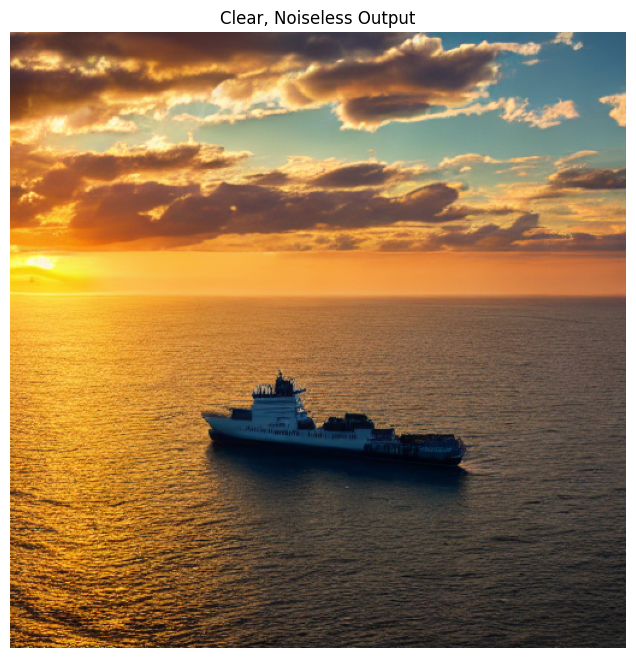

In [66]:
!pip install -q diffusers transformers accelerate

import torch
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt

if torch.cuda.is_available():
    device = "cuda"
    dtype = torch.float16
    print(f"Success! Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = "cpu"
    dtype = torch.float32


pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=dtype,
    low_cpu_mem_usage=True
)
pipe = pipe.to(device)

prompt = "a ship sailing in the ocean at sunset, asthetic in 8k resolution"

print(" Generating clear output")

image = pipe(prompt, num_inference_steps=30).images[0]


plt.figure(figsize=(8,8))
plt.imshow(image)
plt.axis("off")
plt.title("Clear, Noiseless Output")
plt.show()